# Notebook 17 — Learning Curves

**Purpose:** Show that Random Forest generalises with increasing training data.
Uses subject-wise splits (not sklearn's learning_curve which does random splits).

**Output files:**

- `results/figures/learning_curve_rf.png`
- `results/tables/learning_curve_data.csv`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
print("All imports OK")

All imports OK


In [2]:
FEATURE_COLS_FULL = [
    "Mean_RR", "SDNN", "RMSSD", "Mean_HR",
    "Resp_Rate", "Resp_Variability",
    "HRV_HR_Ratio", "Resp_Regularity", "Autonomic_Index"
]

df = pd.read_csv("../data/processed/windows_features_engineered.csv")
df = df.rename(columns={"Subject": "subject_id", "Stress_State": "label"})

X_full   = df[FEATURE_COLS_FULL].values
y_full   = df["label"].values
subjects = df["subject_id"].values
unique_subjects = np.unique(subjects)   # 15 subjects

print(f"Total subjects: {len(unique_subjects)}")
print(f"Total windows:  {len(X_full)}")
print(f"Features:       {len(FEATURE_COLS_FULL)}")

Total subjects: 15
Total windows:  599
Features:       9


In [3]:
train_sizes = [4, 6, 8, 10, 12]
N_TRIALS    = 5

lc_results = []  # list of dicts

for n_train in train_sizes:
    for trial in range(N_TRIALS):
        rng = np.random.default_rng(seed=trial * 100)
        train_subj = rng.choice(unique_subjects, size=n_train, replace=False)
        test_subj  = unique_subjects[~np.isin(unique_subjects, train_subj)]

        train_mask = np.isin(subjects, train_subj)
        test_mask  = np.isin(subjects, test_subj)

        X_tr, y_tr = X_full[train_mask], y_full[train_mask]
        X_te, y_te = X_full[test_mask],  y_full[test_mask]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        model = RandomForestClassifier(n_estimators=300, random_state=42)
        model.fit(X_tr, y_tr)

        train_f1 = f1_score(y_tr, model.predict(X_tr), pos_label=1, zero_division=0)
        test_f1  = f1_score(y_te, model.predict(X_te), pos_label=1, zero_division=0)

        lc_results.append({
            "n_train_subjects": n_train,
            "trial": trial,
            "train_f1": round(train_f1, 4),
            "test_f1": round(test_f1, 4)
        })

        print(f"  n_train={n_train}, trial={trial}: train_F1={train_f1:.3f}, test_F1={test_f1:.3f}")

lc_df = pd.DataFrame(lc_results)
lc_df.to_csv("../results/tables/learning_curve_data.csv", index=False)
print(f"\nSaved: results/tables/learning_curve_data.csv")
print(f"Total experiments: {len(lc_df)}")
lc_df

  n_train=4, trial=0: train_F1=1.000, test_F1=0.360
  n_train=4, trial=1: train_F1=1.000, test_F1=0.550
  n_train=4, trial=2: train_F1=1.000, test_F1=0.573
  n_train=4, trial=3: train_F1=1.000, test_F1=0.592
  n_train=4, trial=4: train_F1=1.000, test_F1=0.562
  n_train=6, trial=0: train_F1=1.000, test_F1=0.629
  n_train=6, trial=1: train_F1=1.000, test_F1=0.615
  n_train=6, trial=2: train_F1=1.000, test_F1=0.578
  n_train=6, trial=3: train_F1=1.000, test_F1=0.619
  n_train=6, trial=4: train_F1=1.000, test_F1=0.627
  n_train=8, trial=0: train_F1=1.000, test_F1=0.410
  n_train=8, trial=1: train_F1=1.000, test_F1=0.651
  n_train=8, trial=2: train_F1=1.000, test_F1=0.627
  n_train=8, trial=3: train_F1=1.000, test_F1=0.523
  n_train=8, trial=4: train_F1=1.000, test_F1=0.538
  n_train=10, trial=0: train_F1=1.000, test_F1=0.607
  n_train=10, trial=1: train_F1=1.000, test_F1=0.618
  n_train=10, trial=2: train_F1=1.000, test_F1=0.314
  n_train=10, trial=3: train_F1=1.000, test_F1=0.726
  n_trai

,n_train_subjects,trial,train_f1,test_f1
0,4,0,1.0,0.3602
1,4,1,1.0,0.5498
2,4,2,1.0,0.5726
3,4,3,1.0,0.5920
4,4,4,1.0,0.5620
5,6,0,1.0,0.6292
6,6,1,1.0,0.6154
7,6,2,1.0,0.5778
8,6,3,1.0,0.6186
9,6,4,1.0,0.6271


In [4]:
# Aggregate stats per training size
agg = lc_df.groupby("n_train_subjects").agg(
    train_f1_mean=("train_f1", "mean"),
    train_f1_std=("train_f1", "std"),
    test_f1_mean=("test_f1", "mean"),
    test_f1_std=("test_f1", "std"),
).reset_index()

print("Aggregated learning curve data:")
agg

Aggregated learning curve data:


,n_train_subjects,train_f1_mean,train_f1_std,test_f1_mean,test_f1_std
0,4,1.0,0.0,0.52732,0.094698
1,6,1.0,0.0,0.61362,0.020830
2,8,1.0,0.0,0.55004,0.095757
3,10,1.0,0.0,0.53726,0.165959
4,12,1.0,0.0,0.62002,0.073040


Saved: results/figures/learning_curve_rf.png


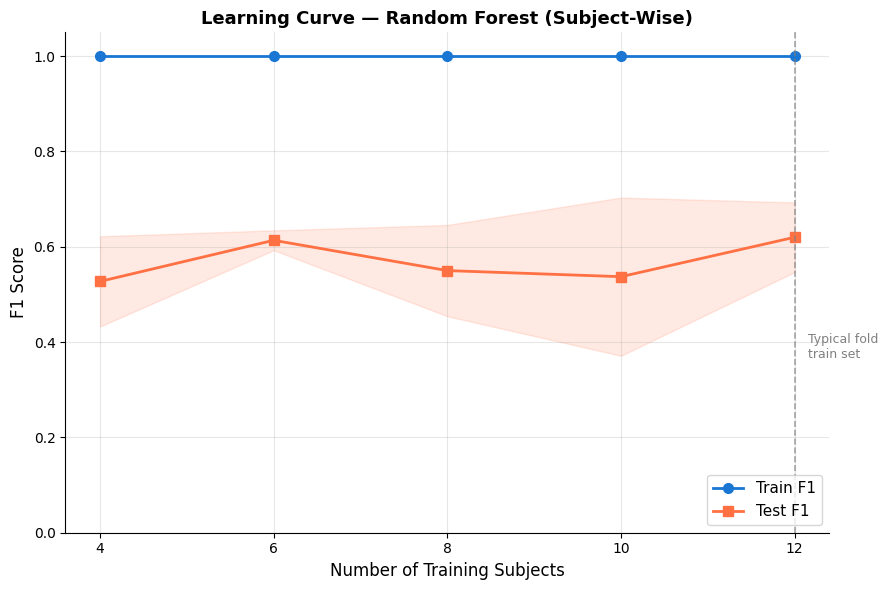

In [5]:
# Learning curve plot
fig, ax = plt.subplots(figsize=(9, 6))

x = agg["n_train_subjects"].values

# Train F1
ax.plot(x, agg["train_f1_mean"], "o-", color="#1976D2", linewidth=2, markersize=7, label="Train F1")
ax.fill_between(x,
                agg["train_f1_mean"] - agg["train_f1_std"],
                agg["train_f1_mean"] + agg["train_f1_std"],
                alpha=0.15, color="#1976D2")

# Test F1
ax.plot(x, agg["test_f1_mean"], "s-", color="#FF7043", linewidth=2, markersize=7, label="Test F1")
ax.fill_between(x,
                agg["test_f1_mean"] - agg["test_f1_std"],
                agg["test_f1_mean"] + agg["test_f1_std"],
                alpha=0.15, color="#FF7043")

# Vertical dashed line at x=12
ax.axvline(x=12, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(12.15, ax.get_ylim()[0] + 0.02, "Typical fold\ntrain set",
        fontsize=9, color="gray", va="bottom")

ax.set_xlabel("Number of Training Subjects", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Learning Curve \u2014 Random Forest (Subject-Wise)", fontsize=13, fontweight="bold")
ax.set_xticks(train_sizes)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc="lower right")
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig("../results/figures/learning_curve_rf.png", dpi=300, bbox_inches="tight")
print("Saved: results/figures/learning_curve_rf.png")
plt.show()